## LangChain v1 

https://docs.langchain.com/oss/python/releases/langchain-v1 

In [1]:
! uv pip install -U langchain

Using Python 3.11.13 environment at: agents_observability/.venv
Resolved 32 packages in 684ms                                        
Audited 32 packages in 0.76ms


In [2]:
import langchain

In [3]:
langchain.__version__

'1.2.0'

### Create Agent with Tools

In [1]:
from dotenv import load_dotenv
load_dotenv()
import os

os.environ["OPENAI_API_KEY"] = os.getenv("OPENAI_API_KEY")

In [2]:
from langchain.agents import create_agent
from langchain.chat_models import init_chat_model
from langchain.tools import tool

c:\Users\10742902\OneDrive - LTIMindtree\Documents\LTIMindtree\Code\data_generation\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [ ]:
llm = init_chat_model(model_provider="openai", model="gpt-5-nano") ### with static model

In [4]:
@tool
def get_order_status(order_id: str) -> str:
    """Return order status based on order ID."""
    order_statuses = {
        "1001": "Shipped",
        "1002": "Processing",
        "1003": "Delivered",
    }
    return order_statuses.get(order_id, "Order ID not found.")

In [5]:
@tool
def get_weather(city: str) -> str:
    """Return the current weather for a given city."""
    weather_data = {
        "New York": "Sunny, 25°C",
        "Los Angeles": "Cloudy, 20°C",
        "Chicago": "Rainy, 15°C",
    }
    return weather_data.get(city, "City not found.")

In [13]:
agent = create_agent(model=llm,
    tools=[get_order_status,get_weather],
    system_prompt='You are a helpful assistant that can provide order status and weather information based on user queries.'
)

In [15]:
response = agent.invoke({'messages': [{'role':'user','content':'What is the status of my order 1002 and what is the weather in New York?'}]})

In [19]:
print(response["messages"][-1].content)

- Order 1002 status: Processing
- Weather in New York: Sunny, 25°C

Would you like me to notify you if the order status changes or provide a forecast for the next few days?


## Middleware Implementation and Functionalities

### 1.0 : Dynamic model with middleware:

Dynamic models are selected at runtime based on the current state and context. This enables sophisticated routing logic and cost optimization.
To use a dynamic model, create middleware using the @wrap_model_call decorator that modifies the model in the request.

In [ ]:
from langchain_openai import ChatOpenAI
from langchain.agents import create_agent
from langchain.agents.middleware import wrap_model_call, ModelRequest, ModelResponse


basic_model = ChatOpenAI(model="gpt-4o-mini")
advanced_model = ChatOpenAI(model="gpt-5-nano")

@wrap_model_call
def dynamic_model_selection(request: ModelRequest, handler) -> ModelResponse:
    """Choose model based on conversation complexity."""
    message_count = len(request.state["messages"])

    if message_count > 5:
        # Use an advanced model for longer conversations
        model = advanced_model
    else:
        model = basic_model

    return handler(request.override(model=model))

agent = create_agent(
    model=basic_model,  # Default model
    tools=[get_order_status, get_weather],
    middleware=[dynamic_model_selection]
)

In [14]:
from langchain_core.messages import HumanMessage, AIMessage, ToolMessage

messages = [
    HumanMessage(content="What's the weather in Delhi?"),
    AIMessage(content="I don't know"),
    HumanMessage(content="Now, what's the status of order 1231?"),
    AIMessage(content="I don't know"),
    HumanMessage(content="What's the weather in Kolkata?"),
    AIMessage(content="It's sunny, 30°C"),
    HumanMessage(content="Tell me order id for 1003"),
]
len(messages)

7

In [15]:
response = agent.invoke({"messages": messages})

In [16]:
response ### used the advanced model : gpt-5-nano

{'messages': [HumanMessage(content="What's the weather in Delhi?", additional_kwargs={}, response_metadata={}, id='58d4cbbc-a294-4d0f-a184-b577082d3fad'),
  AIMessage(content="I don't know", additional_kwargs={}, response_metadata={}, id='ed90caaf-4437-425d-9f52-1f25e1c58657'),
  HumanMessage(content="Now, what's the status of order 1231?", additional_kwargs={}, response_metadata={}, id='e2e42357-903b-481f-96d9-5d93e8ef5b5b'),
  AIMessage(content="I don't know", additional_kwargs={}, response_metadata={}, id='58f5a9d9-8bb8-4a44-9e35-35d349c6fdbe'),
  HumanMessage(content="What's the weather in Kolkata?", additional_kwargs={}, response_metadata={}, id='ba1394ce-84f3-4068-9d37-4f2ee3511ed4'),
  AIMessage(content="It's sunny, 30°C", additional_kwargs={}, response_metadata={}, id='e04909f9-9b9c-44b9-b5a0-149fcb0f388b'),
  HumanMessage(content='Tell me order id for 1003', additional_kwargs={}, response_metadata={}, id='e511c171-45fc-46ce-85bd-0b7db80e22fd'),
  AIMessage(content='Order ID: 1

### 2.0 : Handle tool calling errors (Hooks)

In [6]:
from langchain.agents import create_agent
from langchain.agents.middleware import wrap_tool_call
from langchain.messages import ToolMessage


@wrap_tool_call
def handle_tool_errors(request, handler):
    """Handle tool execution errors with custom messages."""
    try:
        return handler(request)
    except Exception as e:
        # Return a custom error message to the model
        return ToolMessage(
            content=f"Tool error: Please check your input and try again. ({str(e)})",
            tool_call_id=request.tool_call["id"]
        )

@tool
def get_division(a: float, b: float) -> float:
    """Return the division of a by b."""
    return a / b  # This may raise a ZeroDivisionError

agent = create_agent(
    model=llm,
    tools=[get_order_status, get_weather, get_division],
    middleware=[handle_tool_errors]
)

In [7]:
response = agent.invoke({'messages': [{'role': 'user','content': 'Use get_division for Divide 50 by 0'}]})
print(response["messages"][-1].content)

Division by zero is undefined, so the division 50 ÷ 0 cannot be performed. The tool correctly errored because the denominator (b) is zero.

If you’d like, I can:
- Do a safe check and return a clear message like "Cannot divide by zero."
- Compute 50 divided by a nonzero number you specify (e.g., 50 ÷ 5 = 10, 50 ÷ -5 = -10).
- Show the behavior as a limit (infinite), if that helps for understanding, though it’s not a finite number.

How would you like to proceed? Please provide a nonzero divisor or ask for a safe-check result.


In [8]:
response  ### Notice ToolMessage (3rd Message)

{'messages': [HumanMessage(content='Use get_division for Divide 50 by 0', additional_kwargs={}, response_metadata={}, id='3ea5e00e-1bb9-4bb5-b4dc-1a3292faa4a5'),
  AIMessage(content='', additional_kwargs={'refusal': None}, response_metadata={'token_usage': {'completion_tokens': 284, 'prompt_tokens': 189, 'total_tokens': 473, 'completion_tokens_details': {'accepted_prediction_tokens': 0, 'audio_tokens': 0, 'reasoning_tokens': 256, 'rejected_prediction_tokens': 0}, 'prompt_tokens_details': {'audio_tokens': 0, 'cached_tokens': 0}}, 'model_provider': 'openai', 'model_name': 'gpt-5-nano-2025-08-07', 'system_fingerprint': None, 'id': 'chatcmpl-Cj0xrSTuPyKv8yD0nsyZO3JjTvbmX', 'service_tier': 'default', 'finish_reason': 'tool_calls', 'logprobs': None}, id='lc_run--d962cc02-200d-4484-9260-2b2a8aaad136-0', tool_calls=[{'name': 'get_division', 'args': {'a': 50, 'b': 0}, 'id': 'call_l31DNCEk8Gfs6dAFqMrxLoj6', 'type': 'tool_call'}], usage_metadata={'input_tokens': 189, 'output_tokens': 284, 'total_

### 3.0 : Dynamic system prompt (Hooks)

For more advanced use cases where you need to modify the system prompt based on runtime context or agent state, you can use middleware.
The @dynamic_prompt decorator creates middleware that generates system prompts based on the model request.

In [17]:
from typing import TypedDict

from langchain.agents import create_agent
from langchain.agents.middleware import dynamic_prompt, ModelRequest


class Context(TypedDict):
    user_role: str

@dynamic_prompt
def user_role_prompt(request: ModelRequest) -> str:
    """Generate system prompt based on user role."""
    user_role = request.runtime.context.get("user_role", "user")
    base_prompt = "You are a helpful assistant."

    if user_role == "expert":
        return f"{base_prompt} Provide detailed technical responses."
    elif user_role == "beginner":
        return f"{base_prompt} Explain concepts simply and avoid jargon."

    return base_prompt

agent = create_agent(
    model=llm,
    tools=[get_order_status, get_weather],
    middleware=[user_role_prompt],
    context_schema=Context
)

# The system prompt will be set dynamically based on context
response = agent.invoke(
    {"messages": [{"role": "user", "content": "Explain machine learning"}]},
    context={"user_role": "expert"}
)

In [20]:
print(response['messages'][-1].content)

Here’s a structured, technical overview of machine learning (ML).

What it is
- Machine learning is a field of artificial intelligence that focuses on building models that learn patterns from data to make predictions or decisions, rather than being explicitly programmed for every task.
- The core idea is to approximate a function fθ(X) ≈ y, where X is input data, y is the target outcome, and θ are model parameters learned from data.

Core concepts
- Supervised learning: Learn from labeled data (X, y). Tasks include regression (predict a continuous value) and classification (predict a discrete label).
- Unsupervised learning: Learn from unlabeled data to discover structure (e.g., clustering, dimensionality reduction).
- Semi-supervised learning: Uses a mix of labeled and unlabeled data.
- Reinforcement learning: An agent learns by interacting with an environment to maximize cumulative reward.
- Generalization: The model’s ability to perform well on unseen data, not just on the training 

More middleware Builtins:

https://docs.langchain.com/oss/python/langchain/middleware/built-in#configuration-options

Summarization -> Automatically summarize conversation history when approaching token limits.

### 4.0 - SummarizationMiddleware (Context Engineering)

In [ ]:
from langchain.agents import create_agent
from langchain.agents.middleware import SummarizationMiddleware

agent = create_agent(
    model=llm,
    tools=[get_order_status, get_weather],
    middleware=[
        SummarizationMiddleware(
            model=llm,
            trigger=("tokens", 4000),
            keep=("tokens", 1000),
        ),
    ],
)


### 5.0 - Human-in-the-loop
- Pause agent execution for human approval, editing, or rejection of tool calls before they execute. Human-in-the-loop is useful for the following:
- High-stakes operations requiring human approval (e.g. database writes, financial transactions).
- Compliance workflows where human oversight is mandatory.
- Long-running conversations where human feedback guides the agent.

In [40]:
from langchain.agents.middleware import HumanInTheLoopMiddleware
from langgraph.checkpoint.memory import InMemorySaver

agent = create_agent(
    model=llm,
    tools=[get_order_status, get_weather],
    checkpointer=InMemorySaver(),
    middleware=[
        HumanInTheLoopMiddleware(
            interrupt_on={
                "get_order_status": {
                    "allowed_decisions": ["approve", "edit", "reject"],
                },
                "get_weather": False,
            }
        ),
    ],
)

In [41]:
import uuid
thread_id = str(uuid.uuid4())
config = {"configurable": {"thread_id": thread_id}}


In [ ]:
result = agent.invoke({'messages': [{'role':'user','content':'Get me status of order 1001'}]}, 
                      config=config)

In [ ]:
# Inspecting the Interrupt Result ---
if result.get("__interrupt__"):
    interrupt_data = result["__interrupt__"][0].value
    action_request = interrupt_data["action_requests"][0]
    
    print("Execution Paused! Human Review Required.")
    print(f"Tool Proposed: {action_request['name']}")
    print(f"Arguments: {action_request['args']}")
    # The agent state is now saved in the checkpointer using 'thread_id'.
else:
    print("Agent finished without interruption.")

Execution Paused! Human Review Required.
Tool Proposed: get_order_status
Arguments: {'order_id': '1001'}


In [44]:
# Human Decision (Approve) ---
# Create the decision object for the interrupt.
# The 'type' can be 'approve', 'edit', or 'reject'.

from langgraph.types import Command

decision_to_approve = [{
    "type": "approve"
    # For 'approve', no other fields are strictly needed
}]


# Resume execution using the LangGraph Command structure
resume_command = Command(resume={"decisions": decision_to_approve})

# Invoke the agent again with the *same* config and the resume command.
result_resumed = agent.invoke(
    resume_command,
    config=config
)

# Inspecting the Resumed Result ---
# The agent executes the approved tool call and then generates a final response.
print("Execution Resumed and Completed.")

print(f"Final Agent Response: {result_resumed['messages'][-1].content}")

Execution Resumed and Completed.
Final Agent Response: Order 1001 status: Shipped.

Would you like me to fetch tracking details or the estimated delivery date if available?


### 6.0 - Model fallback
Automatically fallback to alternative models when the primary model fails. Model fallback is useful for the following:

- Building resilient agents that handle model outages.
- Cost optimization by falling back to cheaper models.
- Provider redundancy across OpenAI, Anthropic, etc.

In [47]:
# ! pip install -U langchain-anthropic

In [ ]:
from langchain.agents import create_agent
from langchain.agents.middleware import ModelFallbackMiddleware

agent = create_agent(
    model="gpt-4o",
    tools=[get_order_status, get_weather],
    middleware=[
        ModelFallbackMiddleware(
            "gpt-4o-mini",
            "claude-3-5-sonnet-20241022",
        ),
    ],
)

### 7.0 - PII detection
Detect and handle Personally Identifiable Information (PII) in conversations using configurable strategies. PII detection is useful for the following:

- Healthcare and financial applications with compliance requirements.
- Customer service agents that need to sanitize logs.
- Any application handling sensitive user data.

In [ ]:
from langchain.agents import create_agent
from langchain.agents.middleware import PIIMiddleware

agent = create_agent(
    model="gpt-4o",
    tools=[get_order_status, get_weather],
    middleware=[
        PIIMiddleware("email", strategy="redact", apply_to_input=True),
        PIIMiddleware("credit_card", strategy="mask", apply_to_input=True),
    ],
)

In [ ]:
# custom: Regex pattern string
agent1 = create_agent(
    model="gpt-4o",
    tools=[],
    middleware=[
        PIIMiddleware(
            "api_key",
            detector=r"sk-[a-zA-Z0-9]{32}",
            strategy="block",
        ),
    ],
)

### 8.0 - (Hooks) Before and after model call and Custom State Schema:

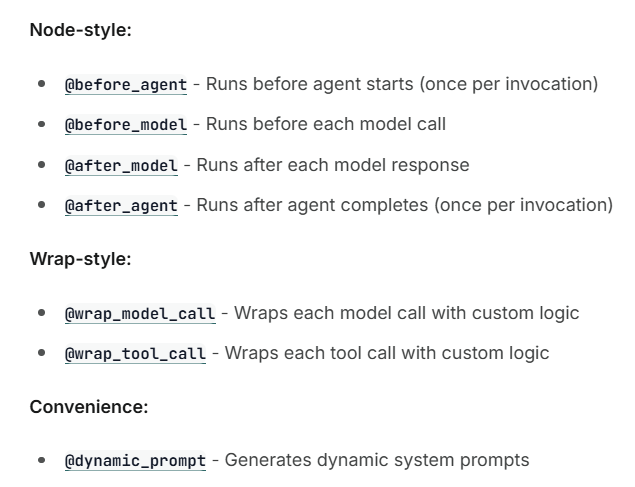

- Track state across execution: Maintain counters, flags, or other values that persist throughout the agent’s execution lifecycle
- Share data between hooks: Pass information from before_model to after_model or between different middleware instances
- Implement cross-cutting concerns: Add functionality like rate limiting, usage tracking, user context, or audit logging without modifying the core agent logic
- Make conditional decisions: Use accumulated state to determine whether to continue execution, jump to different nodes, or modify behavior dynamically

In [51]:
from langchain.agents import create_agent
from langchain.messages import HumanMessage
from langchain.agents.middleware import AgentState, before_model, after_model
from typing_extensions import NotRequired
from typing import Any
from langgraph.runtime import Runtime


class CustomState(AgentState):
    model_call_count: NotRequired[int]
    user_id: NotRequired[str]


@before_model(state_schema=CustomState, can_jump_to=["end"])
def check_call_limit(state: CustomState, runtime: Runtime) -> dict[str, Any] | None:
    count = state.get("model_call_count", 0)
    if count > 10:
        return {"jump_to": "end"}
    return None


@after_model(state_schema=CustomState)
def increment_counter(state: CustomState, runtime: Runtime) -> dict[str, Any] | None:
    return {"model_call_count": state.get("model_call_count", 0) + 1}


agent = create_agent(
    model=llm,
    middleware=[check_call_limit, increment_counter],
    tools=[],
)

# Invoke with custom state
result = agent.invoke({
    "messages": [HumanMessage("Hello")],
    "model_call_count": 0,
    "user_id": "user-123",
})

In [52]:
result

{'messages': [HumanMessage(content='Hello', additional_kwargs={}, response_metadata={}, id='2172107c-55cf-4e3a-889f-76d51eba5016'),
  AIMessage(content='Hi there! How can I help today? If you’re not sure where to start, you can tell me a topic or task you’re interested in, or pick from these:\n\n- Explain a concept or answer a question\n- Help with homework or coding\n- Write, edit, or brainstorm ideas\n- Plan something (trip, project, resume)\n- Practice a language\n\nWhat would you like to do?', additional_kwargs={'refusal': None}, response_metadata={'token_usage': {'completion_tokens': 284, 'prompt_tokens': 7, 'total_tokens': 291, 'completion_tokens_details': {'accepted_prediction_tokens': 0, 'audio_tokens': 0, 'reasoning_tokens': 192, 'rejected_prediction_tokens': 0}, 'prompt_tokens_details': {'audio_tokens': 0, 'cached_tokens': 0}}, 'model_provider': 'openai', 'model_name': 'gpt-5-nano-2025-08-07', 'system_fingerprint': None, 'id': 'chatcmpl-CjMfsWaU39kT3QqoR6KsYRLf0hstf', 'servic

### Generate Structured Response from tool calling response

In [21]:
@tool
def get_user_info(user_id: str) -> dict:
    """Return user information based on user ID."""
    users = {
        "1074": {"name": "Alice", "designation": "Engineer", "email_id": "alice@example.com"},
        "2076": {"name": "Bob", "designation": "Manager", "email_id": "bob@example.com"},
        "3009": {"name": "Charlie", "designation": "Analyst", "email_id": "charlie@example.com"},
    }
    return users.get(user_id, {"name": "Unknown", "designation": "Unknown", "email_id": "Unknown"})

In [23]:
from pydantic import BaseModel
class UserInfoResponse(BaseModel):
    name: str
    designation: str
    email_id: str

In [25]:
agent = create_agent(
    model=llm,
    tools=[get_user_info],
    system_prompt="You are an assistant that provides user information in a structured format.",
    response_format=UserInfoResponse
)

In [26]:
response = agent.invoke({'messages': [{'role':'user','content':'Show me details of user id 1074'}]})

In [29]:
# Structured response

response['messages'][-1].content

'{"name":"Alice","designation":"Engineer","email_id":"alice@example.com"}'

## Standard content blocks

- langchain-anthropic
- langchain-aws
- langchain-openai
- langchain-google-genai
- langchain-ollama


The new content_blocks property introduces a standard representation for message content that works across providers:

In [6]:
# ! uv pip install langchain_anthropic

In [7]:
from langchain_anthropic import ChatAnthropic
from langchain_openai import ChatOpenAI

#llm = ChatAnthropic(model="claude-sonnet-4-5-20250929")
llm = ChatOpenAI(model="gpt-4o-mini")

response = llm.invoke("What's the capital of India?")

# Unified access to content blocks
for block in response.content_blocks:
    if block["type"] == "reasoning":
        print(f"Model reasoning: {block['reasoning']}")
    elif block["type"] == "text":
        print(f"Response: {block['text']}")
    elif block["type"] == "tool_call":
        print(f"Tool call: {block['name']}({block['args']})")

Response: The capital of India is New Delhi.


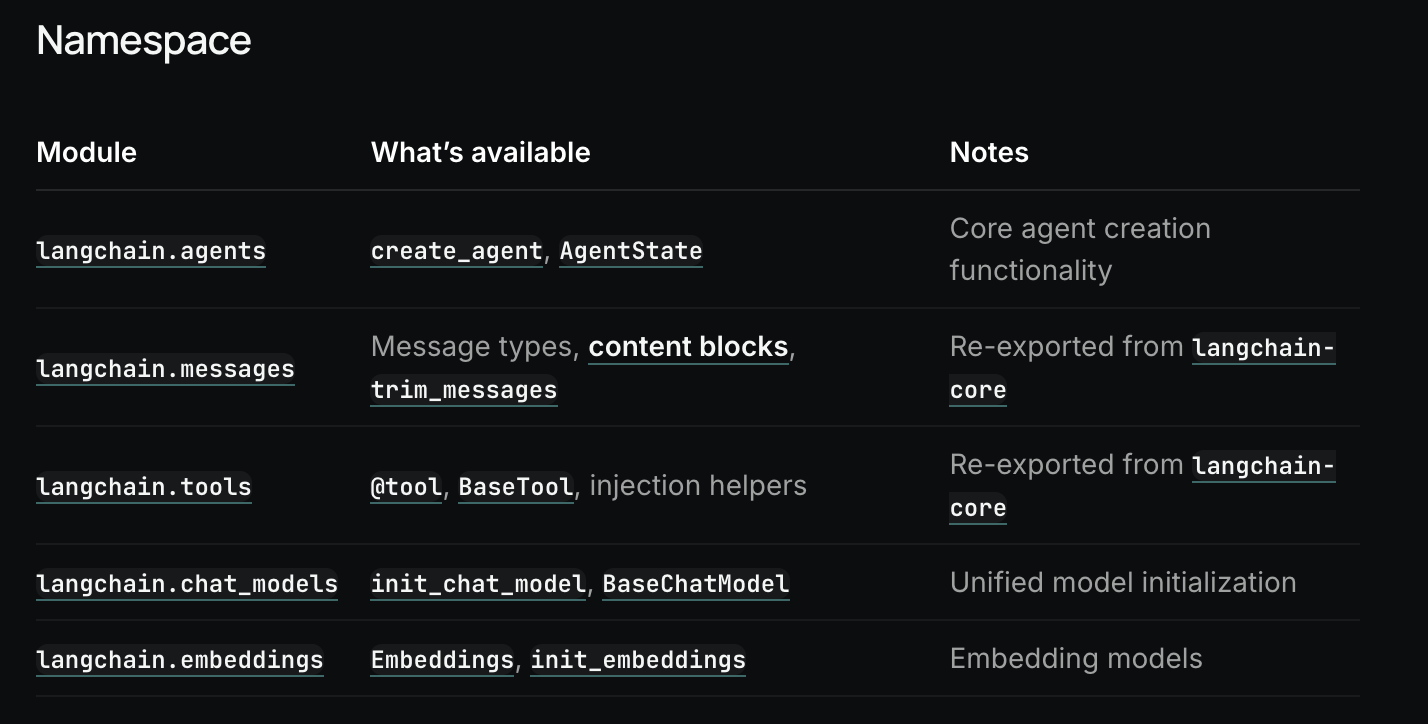

In [ ]:
# Agent building
from langchain.agents import create_agent

# Messages and content
from langchain.messages import AIMessage, HumanMessage

# Tools
from langchain.tools import tool

# Model initialization
from langchain.chat_models import init_chat_model
from langchain.embeddings import init_embeddings